<a href="https://colab.research.google.com/github/omarilzz/Customer-Support-AI-System/blob/main/CSAIS_Projekt_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Support AI System Projekt ⚡




In [ ]:
import os

# Creating folders for the projekt
folders = ['data', 'models', 'api', 'app']

for folder in folders:
  os.makedirs(folder, exist_ok=True)

# Creating an empty README.md to get started [GITHUB]
with open('README.md', 'w') as f:
    f.write("# Customer Support AI System\n\nProject Overview placeholder.")

print("Repository structure initialized.")

Repository structure initialized.


In [ ]:
#Importing essentials and needed libs and etc..

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
# Loading up datasets
df_train = pd.read_csv('/content/data/SaaS_Tech_data.csv')
df_faq = pd.read_csv('/content/data/faq_saas.csv')


In [ ]:
# Data Checkup

print("--- SaaS Training Data ---")
print(df_train.head())
print("Columns:", df_train.columns.tolist())

print("\n--- FAQ Data ---")
print(df_faq.head())
print("Columns:", df_faq.columns.tolist())


--- SaaS Training Data ---
    ticket_id     industry   category priority sentiment  \
0  TKT-000001  SaaS / Tech    billing     high  negative   
1  TKT-000003  SaaS / Tech  technical     high  negative   
2  TKT-000009  SaaS / Tech    billing   medium  positive   
3  TKT-000010  SaaS / Tech    billing      low  negative   
4  TKT-000012  SaaS / Tech  technical     high  negative   

                                      title  \
0  Charged $217 for feature never activated   
1         SAML SSO broken after v4.1 update   
2              Annual plan invoiced monthly   
3      Mobile app data sync delay 2–6 hours   
4         OAuth token refresh returning 401   

                                         description created_date channel  \
0  Hello,\n\nInvoice includes $217 for Enterprise...   2025-12-06    chat   
1  Good afternoon,\n\nSSO with Azure AD broken si...   2025-05-12     web   
2  Good afternoon,\n\nSwitched to annual plan on ...   2025-03-09     web   
3  Dear support team,

In [ ]:
# Processing data

# 1. Check for missing values
print("--- Missing Values ---")
print(df_train.isnull().sum())

# 2. Check for duplicates
print("\n--- Duplicate Rows ---")
print(df_train.duplicated().sum())

# 3. Check unique values for the target labels
# This tells us how many categories/priorities we are actually predicting
print("\n--- Unique Categories ---")
print(df_train['category'].value_counts())
print("\n--- Unique Priorities ---")
print(df_train['priority'].value_counts())



--- Missing Values ---
ticket_id                0
industry                 0
category                 0
priority                 0
sentiment                0
title                    0
description              0
created_date             0
channel                  0
resolution_time_hours    0
dtype: int64

--- Duplicate Rows ---
0

--- Unique Categories ---
category
technical    3306
billing      3296
account      3291
delivery      106
Name: count, dtype: int64

--- Unique Priorities ---
priority
high      5257
medium    3359
low       1383
Name: count, dtype: int64


In [ ]:
# Clearing the unneeded

# Columns: ['ticket_id', 'industry', 'category', 'priority', 'sentiment', 'title', 'description', 'created_date', 'channel', 'resolution_time_hours']

#Creating a col for a single text feature for future use "not to waste"
df_train['raw_text'] = df_train['title'] + " " + df_train['description']

# Dropping the unneeded
cols_to_drop = ['ticket_id', 'industry', 'created_date', 'title', 'description']

# Creating clean dataframe
df_cleaned = df_train.drop(columns=cols_to_drop)

# Verfying everything in order
print("Final Columns List:")
print(df_cleaned.columns.tolist())
print("\nFirst 5 rows of the cleaned data:")
print(df_cleaned.head())




Final Columns List:
['category', 'priority', 'sentiment', 'channel', 'resolution_time_hours', 'raw_text']

First 5 rows of the cleaned data:
    category priority sentiment channel  resolution_time_hours  \
0    billing     high  negative    chat                      1   
1  technical     high  negative     web                      8   
2    billing   medium  positive     web                     48   
3    billing      low  negative  mobile                     72   
4  technical     high  negative   email                      8   

                                            raw_text  
0  Charged $217 for feature never activated Hello...  
1  SAML SSO broken after v4.1 update Good afterno...  
2  Annual plan invoiced monthly Good afternoon,\n...  
3  Mobile app data sync delay 2–6 hours Dear supp...  
4  OAuth token refresh returning 401 Good afterno...  


/tmp/ipykernel_1398/2136496662.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x= 'category', palette='viridis')


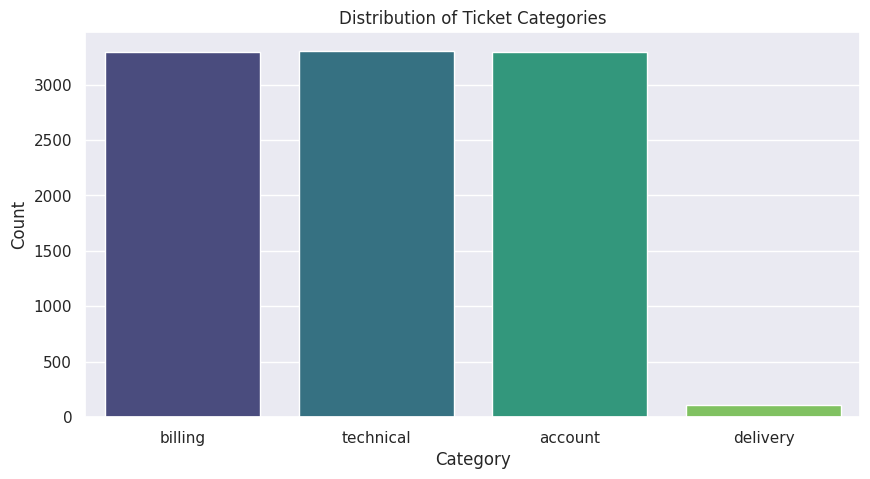

/tmp/ipykernel_1398/2136496662.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='priority', palette='magma')


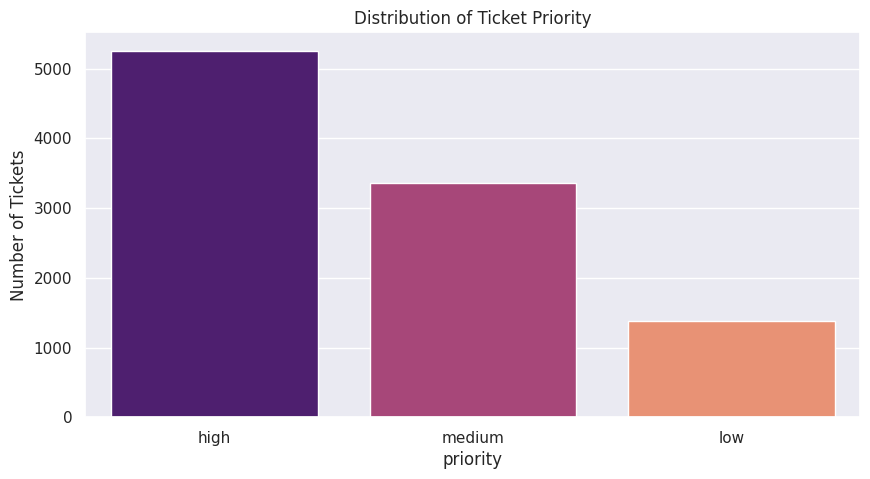

--- Resolution Time Statistics (Hours) ---
count    9999.000000
mean       32.447245
std        37.718318
min         1.000000
25%         8.000000
50%        12.000000
75%        48.000000
max       168.000000
Name: resolution_time_hours, dtype: float64


In [ ]:
# Visualization

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x= 'category', palette='viridis')
plt.title('Distribution of Ticket Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x='priority', palette='magma')
plt.title('Distribution of Ticket Priority')
plt.ylabel('Number of Tickets')
plt.show()

#RTS

print("--- Resolution Time Statistics (Hours) ---")
print(df_cleaned['resolution_time_hours'].describe())



In [ ]:
# Check the target labels
print("--- Category Target Classes ---")
print(df_cleaned['category'].unique())

print("\n--- Priority Target Classes ---")
print(df_cleaned['priority'].unique())

# Verify target count
print(f"\nTotal samples to train on: {len(df_cleaned)}")

--- Category Target Classes ---
['billing' 'technical' 'account' 'delivery']

--- Priority Target Classes ---
['high' 'medium' 'low']

Total samples to train on: 9999


In [ ]:
#Training OPS

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import joblib

# keeping raw_text, priority, and channel as inputs
X = df_cleaned[['raw_text', 'priority', 'channel']]
y = df_cleaned['category']

# Based on visualization data needs to be Stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Creating the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=5000), 'raw_text'),
        ('cat', OneHotEncoder(), ['priority', 'channel'])
    ]
)

# The Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline.fit(X_train, y_train)

# Evaluate and Save
y_pred = pipeline.predict(X_test)
print("--- Final Model Performance Report ---")
print(classification_report(y_test, y_pred))

joblib.dump(pipeline, '/content/models/saas_category_model.pkl')
print("\nModel saved successfully as 'category_model.pkl'.")

--- Final Model Performance Report ---
              precision    recall  f1-score   support

     account       0.97      0.98      0.98       658
     billing       0.96      0.97      0.97       659
    delivery       0.00      0.00      0.00        21
   technical       0.97      0.98      0.97       662

    accuracy                           0.97      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.96      0.97      0.96      2000


Model saved successfully as 'category_model.pkl'.


In [ ]:
#Recall is bad in delivery due to low sample data
#Taking another route [Testing SMOTE]

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=5000), 'raw_text'),
        ('cat', OneHotEncoder(), ['priority', 'channel'])
    ]
)

pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     account       0.97      0.98      0.98       658
     billing       0.97      0.97      0.97       659
    delivery       0.00      0.00      0.00        21
   technical       0.97      0.97      0.97       662

    accuracy                           0.97      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.96      0.97      0.96      2000



In [ ]:
#Checking Delivery

print(df_cleaned[df_cleaned['category'] == 'delivery']['raw_text'].head(10))

12     Partner discount missing from renewal Catalyst...
29     Invoice PDF download returns 403 error 'Downlo...
384    OAuth token refresh returning 401 Hi,\n\nI can...
598    Rate limiting triggering below threshold I'm h...
651    Admin cannot assign custom roles Workspace adm...
708    Tax exemption not applied Good morning,\n\nSub...
758    Tax exemption not applied Hello,\n\nI'm having...
808    Proration charge on invoice makes no sense Goo...
825    Audit logs missing critical actions Hey,\n\nCo...
948    Credit card on file expired but no notificatio...
Name: raw_text, dtype: object


In [ ]:
# Delivery is creating a vocab noise and the model refuses it

# Removing the noisy category
df_cleaned = df_cleaned[df_cleaned['category'] != 'delivery']

X = df_cleaned[['raw_text', 'priority', 'channel']]
y = df_cleaned['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline.fit(X_train, y_train)

# Evaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     account       0.97      0.98      0.98       658
     billing       0.98      0.97      0.97       659
   technical       0.98      0.98      0.98       662

    accuracy                           0.98      1979
   macro avg       0.98      0.98      0.98      1979
weighted avg       0.98      0.98      0.98      1979



In [ ]:
# Replacing the old broken model due to data noise
joblib.dump(pipeline, '/content/models/saas_category_model.pkl')
print("Voilà!")

Voilà!


# **Resolution Time Estimation** ⏲ ⚡

In [ ]:
df_cleaned.info()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9893 entries, 0 to 9998
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   category               9893 non-null   object
 1   priority               9893 non-null   object
 2   sentiment              9893 non-null   object
 3   channel                9893 non-null   object
 4   resolution_time_hours  9893 non-null   int64 
 5   raw_text               9893 non-null   object
dtypes: int64(1), object(5)
memory usage: 541.0+ KB


,category,priority,sentiment,channel,resolution_time_hours,raw_text
0,billing,high,negative,chat,1,Charged $217 for feature never activated Hello...
1,technical,high,negative,web,8,SAML SSO broken after v4.1 update Good afterno...
2,billing,medium,positive,web,48,"Annual plan invoiced monthly Good afternoon,\n..."
3,billing,low,negative,mobile,72,Mobile app data sync delay 2–6 hours Dear supp...
4,technical,high,negative,email,8,OAuth token refresh returning 401 Good afterno...


In [ ]:
# To avoid any data confusions im going to clone the data frame

df_model = df_cleaned.copy()

# Applying the same mapping

priority_map = {'high': 3, 'medium': 2, 'low': 1}
df_model['priority_numeric'] = df_model['priority'].map(priority_map)

sentiment_map = {'positive': 3, 'neutral': 2, 'negative': 1}
df_model['sentiment_numeric'] = df_model['sentiment'].map(sentiment_map)

# Remove the raws
df_model = df_model.drop(columns=['priority', 'sentiment'])

# Checkup
print(df_model.columns.tolist())
print('-------------------')
df_model.info()
df_model.head()



['category', 'channel', 'resolution_time_hours', 'raw_text', 'priority_numeric', 'sentiment_numeric']
-------------------
<class 'pandas.core.frame.DataFrame'>
Index: 9893 entries, 0 to 9998
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   category               9893 non-null   object
 1   channel                9893 non-null   object
 2   resolution_time_hours  9893 non-null   int64 
 3   raw_text               9893 non-null   object
 4   priority_numeric       9893 non-null   int64 
 5   sentiment_numeric      9893 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 541.0+ KB


,category,channel,resolution_time_hours,raw_text,priority_numeric,sentiment_numeric
0,billing,chat,1,Charged $217 for feature never activated Hello...,3,1
1,technical,web,8,SAML SSO broken after v4.1 update Good afterno...,3,1
2,billing,web,48,"Annual plan invoiced monthly Good afternoon,\n...",2,3
3,billing,mobile,72,Mobile app data sync delay 2–6 hours Dear supp...,1,1
4,technical,email,8,OAuth token refresh returning 401 Good afterno...,3,1


In [ ]:
# SLAs are breaking the model
# Need to add awareness

def get_sla_limit(row):
    if row['priority_numeric'] == 3: # Assuming 3 is High
        return 48
    elif row['priority_numeric'] == 2: # Assuming 2 is Mid
        return 96
    else: # Low
        return 168

df_model['sla_limit'] = df_model.apply(get_sla_limit, axis=1)
df_model.head()

,category,channel,resolution_time_hours,raw_text,priority_numeric,sentiment_numeric,sla_limit
0,billing,chat,1,Charged $217 for feature never activated Hello...,3,1,48
1,technical,web,8,SAML SSO broken after v4.1 update Good afterno...,3,1,48
2,billing,web,48,"Annual plan invoiced monthly Good afternoon,\n...",2,3,96
3,billing,mobile,72,Mobile app data sync delay 2–6 hours Dear supp...,1,1,168
4,technical,email,8,OAuth token refresh returning 401 Good afterno...,3,1,48


In [ ]:
print(df_model.columns)

Index(['category', 'channel', 'resolution_time_hours', 'raw_text',
       'priority_numeric', 'sentiment_numeric', 'sla_limit'],
      dtype='object')


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Features and Target
features = ['category', 'channel', 'raw_text', 'priority_numeric', 'sentiment_numeric', 'sla_limit']
target = ['resolution_time_hours']
X = df_model[features]
y = df_model[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the preprocessor (using our established logic)
preprocessor_reg = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=5000), 'raw_text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['category', 'channel']),
        ('num', 'passthrough', ['priority_numeric', 'sentiment_numeric', 'sla_limit'])
    ]
)

# Pipeline and Train
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

reg_pipeline.fit(X_train, y_train.values.ravel())

# Evaluate
y_pred = reg_pipeline.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

R2 Score: 0.42


In [ ]:
# Low score assuming due to incident resolution times may go out of SLA or avg res time
df_model['resolution_time_hours'].describe()

,resolution_time_hours
count,9893.000000
mean,32.457596
std,37.698588
min,1.000000
25%,8.000000
50%,12.000000
75%,48.000000
max,168.000000


In [ ]:
# We learn that Max hrs are 168hrs

# Convert y_pred to a Series with the same index as y_test
y_pred_series = pd.Series(y_pred, index=y_test.index)

# Now calculate the errors
errors = y_test - y_pred_series

# Inspect the results
print(errors.describe())

         0    3    8   10   13   15   18   20   21   24  ...  9957  9959  \
count  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   
mean   NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
std    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
min    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
25%    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
50%    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
75%    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
max    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   

       9963  9964  9973  9988  9992  9997  9998  resolution_time_hours  
count   0.0   0.0   0.0   0.0   0.0   0.0   0.0                    0.0  
mean    NaN   NaN   NaN   NaN   NaN   NaN   NaN                    NaN  
std     NaN   NaN   NaN   NaN   NaN   NaN   NaN                    NaN  
min     NaN   NaN   NaN

In [ ]:
# Force them to be 1D numpy arrays right at the calculation moment
error_values = y_test.values.flatten() - reg_pipeline.predict(X_test).flatten()

# Display the stats
print(pd.Series(error_values).describe())

count    1979.000000
mean        0.929629
std        29.099128
min       -96.720000
25%       -14.375000
50%        -4.040000
75%        14.685000
max       121.440000
dtype: float64


In [ ]:
# Going to try pattern matching using creation time
# Reimporting OG DF
df_og = pd.read_csv('/content/data/SaaS_Tech_data.csv')
# Triming to align data
df_og_clean = df_og[df_og['category'] != 'delivery'].copy()
# Here we go
df_model['created_date'] = pd.to_datetime(df_og_clean['created_date'])
df_model['day_of_week'] = df_model['created_date'].dt.dayofweek
df_model['hour_of_day'] = df_model['created_date'].dt.hour
#Raw data removal
df_model = df_model.drop(columns=['created_date'])

features = ['category', 'channel', 'raw_text', 'priority_numeric',
            'sentiment_numeric', 'sla_limit', 'day_of_week', 'hour_of_day']
target = ['resolution_time_hours']

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=5000), 'raw_text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['category', 'channel']),
        ('num', 'passthrough', ['priority_numeric', 'sentiment_numeric', 'sla_limit', 'day_of_week', 'hour_of_day'])
    ]
)

reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

reg_pipeline.fit(X_train, y_train.values.ravel())
print(f"New R2 Score with Time Features: {reg_pipeline.score(X_test, y_test):.2f}")

New R2 Score with Time Features: 0.43


New R2 Score with Scaling & Reduced Text: 0.43


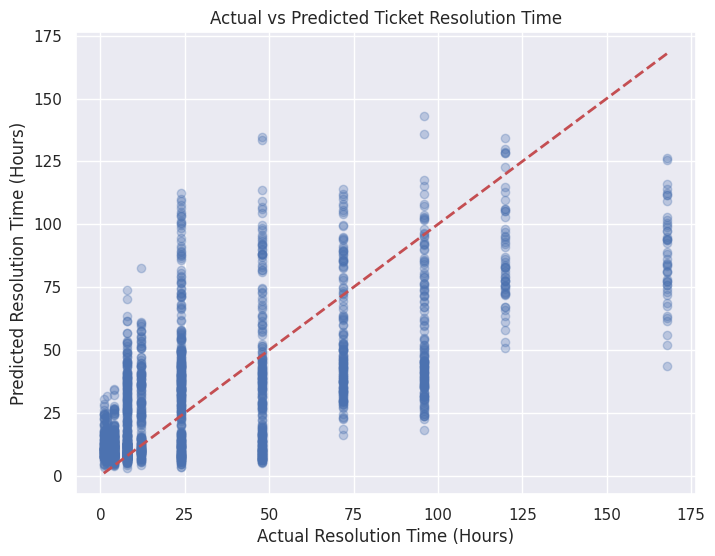

Model saved successfully as saas_resolution_model.pkl


In [ ]:
# Going to try pattern matching using creation time
from sklearn.preprocessing import StandardScaler
# Reimporting OG DF
df_og = pd.read_csv('/content/data/SaaS_Tech_data.csv')
# Triming to align data
df_og_clean = df_og[df_og['category'] != 'delivery'].copy()
# Here we go
df_model['created_date'] = pd.to_datetime(df_og_clean['created_date'])
df_model['day_of_week'] = df_model['created_date'].dt.dayofweek
df_model['hour_of_day'] = df_model['created_date'].dt.hour
#Raw data removal
df_model = df_model.drop(columns=['created_date'])

features = ['category', 'channel', 'raw_text', 'priority_numeric',
            'sentiment_numeric', 'sla_limit', 'day_of_week', 'hour_of_day']
target = ['resolution_time_hours']

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words='english', max_features=500), 'raw_text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['category', 'channel']),
        ('num', StandardScaler(), ['priority_numeric', 'sentiment_numeric', 'sla_limit', 'day_of_week', 'hour_of_day'])
    ]
)

# 2. Re-initialize and fit the pipeline
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

reg_pipeline.fit(X_train, y_train.values.ravel())
print(f"New R2 Score with Scaling & Reduced Text: {reg_pipeline.score(X_test, y_test):.2f}")
# Generate predictions
y_pred = reg_pipeline.predict(X_test)

# Plot actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Resolution Time (Hours)')
plt.ylabel('Predicted Resolution Time (Hours)')
plt.title('Actual vs Predicted Ticket Resolution Time')
plt.show()

import joblib #its imported before but making sure
joblib.dump(reg_pipeline, '/content/models/saas_resolution_model.pkl')
print("Model saved successfully as saas_resolution_model.pkl")

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9893 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   category               9893 non-null   object
 1   channel                9893 non-null   object
 2   resolution_time_hours  9893 non-null   int64 
 3   raw_text               9893 non-null   object
 4   priority_numeric       9893 non-null   int64 
 5   sentiment_numeric      9893 non-null   int64 
 6   sla_limit              9893 non-null   int64 
 7   day_of_week            9893 non-null   int32 
 8   hour_of_day            9893 non-null   int32 
dtypes: int32(2), int64(4), object(3)
memory usage: 695.6+ KB


# **API Time** 🦾

In [30]:
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

# Loading the model
model = joblib.load('/content/models/saas_resolution_model.pkl')

@app.post("/predict")
def predict(data: dict):
    # Create the DataFrame
    df = pd.DataFrame([data])

    # Fill missing columns with defaults to match model requirements
    df['day_of_week'] = 0
    df['priority_numeric'] = 1
    df['channel'] = 'email'
    df['category'] = 'general'
    df['raw_text'] = data.get('text', '')
    df['hour_of_day'] = 12
    df['sla_limit'] = 24
    df['sentiment_numeric'] = 0.5

    # Run prediction
    prediction = model.predict(df)
    return {"prediction": prediction.tolist()}

# **APP UI** 💾

In [32]:
#pip install streamlit fastapi uvicorn requests
#streamlit run /content/app/app.py &>/content/logs.txt &
#npx localtunnel --port 8501
import streamlit as st
import requests

st.title("Customer Support AI System")
ticket_text = st.text_area("Enter Ticket Description")

if st.button("Predict"):
    st.write("Sending request to API...") # Feedback
    try:
        # Use a short timeout so it doesn't hang forever
        response = requests.post("http://127.0.0.1:8000/predict", json={"text": ticket_text}, timeout=10)

        if response.status_code == 200:
            st.success(f"Result: {response.json()['prediction']}")
        else:
            st.error(f"API returned status {response.status_code}")
            st.write(response.text)
    except Exception as e:
        st.error(f"Error: {e}")

2026-07-12 17:58:13.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.633 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 17:58:13.635 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [33]:
# Exporting the files

# 2. Save the API code to a file
api_code = """from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

# Loading the model
model = joblib.load('/content/models/saas_resolution_model.pkl')

@app.post("/predict")
def predict(data: dict):
    # Create the DataFrame
    df = pd.DataFrame([data])

    # Fill missing columns with defaults to match model requirements
    df['day_of_week'] = 0
    df['priority_numeric'] = 1
    df['channel'] = 'email'
    df['category'] = 'general'
    df['raw_text'] = data.get('text', '')
    df['hour_of_day'] = 12
    df['sla_limit'] = 24
    df['sentiment_numeric'] = 0.5

    # Run prediction
    prediction = model.predict(df)
    return {"prediction": prediction.tolist()}
"""

with open('/content/api/main.py', 'w') as f:
    f.write(api_code)

# 3. Save the App code to a file
app_code = """import streamlit as st
import requests

st.title("Customer Support AI System")
ticket_text = st.text_area("Enter Ticket Description")

if st.button("Predict"):
    st.write("Sending request to API...") # Feedback
    try:
        # Use a short timeout so it doesn't hang forever
        response = requests.post("http://127.0.0.1:8000/predict", json={"text": ticket_text}, timeout=10)

        if response.status_code == 200:
            st.success(f"Result: {response.json()['prediction']}")
        else:
            st.error(f"API returned status {response.status_code}")
            st.write(response.text)
    except Exception as e:
        st.error(f"Error: {e}")
"""

with open('/content/app/app.py', 'w') as f:
    f.write(app_code)

print("Files saved successfully to the disk!")

Files saved successfully to the disk!
